# Phase 1: PPG-Only Blood Pressure Dataset Cleaning, Validation & Visualization

**Project Objective**: Establish a clean, validated, scientifically reproducible dataset foundation for cuffless blood pressure estimation using **Photoplethysmography (PPG) alone**, in preparation for future embedded deployment with an ESP32 + MAX30102 hardware platform.

> **Research Constraints for Phase 1**:
> - No machine learning or deep learning models are trained in this phase.
> - Raw `.mat` dataset files in `BloodPressureDataset/` remain 100% immutable.
> - Channel 2 (ECG) is completely omitted from all processing.
> - ABP is utilized exclusively as ground-truth reference for validation and target extraction.

## 1. Project Configuration

In [1]:
import sys
from pathlib import Path

# Ensure project root 'code' is on sys.path
NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from config.config import (
    DATASET_DIR,
    OUTPUT_DIR,
    STATISTICS_DIR,
    FIGURES_DIR,
    SAMPLING_RATE,
    PPG_BANDPASS_LOWCUT,
    PPG_BANDPASS_HIGHCUT,
    QC_MANIFEST_FILENAME,
    QC_REPORT_FILENAME
)
from utils.logging_utils import setup_logger

logger = setup_logger("notebook_analysis")
print(f"Project Code Directory : {CODE_DIR}")
print(f"Raw Dataset Directory  : {DATASET_DIR}")
print(f"Figures Output Path    : {FIGURES_DIR}")
print(f"Sampling Frequency     : {SAMPLING_RATE} Hz")

Project Code Directory : /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/code
Raw Dataset Directory  : /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/BloodPressureDataset
Figures Output Path    : /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/code/outputs/figures
Sampling Frequency     : 125 Hz


## 2. Environment Verification

In [2]:
import numpy as np
import scipy
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import h5py
import tqdm

print("=== Virtual Environment Package Check ===")
print(f"Python Version : {sys.version.split()[0]}")
print(f"NumPy          : {np.__version__}")
print(f"SciPy          : {scipy.__version__}")
print(f"Pandas         : {pd.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"H5Py           : {h5py.__version__}")
print("✅ Environment verification successful (Kernel: PPG BP)")

=== Virtual Environment Package Check ===
Python Version : 3.10.21
NumPy          : 2.2.6
SciPy          : 1.15.2
Pandas         : 2.3.3
Matplotlib     : 3.10.9
Seaborn        : 0.13.2
Scikit-learn   : 1.7.2
H5Py           : 3.16.0
✅ Environment verification successful (Kernel: PPG BP)


## 3. Dataset Discovery

In [3]:
from data.loader import get_mat_files

mat_files = get_mat_files()
print(f"Discovered {len(mat_files)} MATLAB dataset parts:")
total_bytes = 0
for f in mat_files:
    sz_mb = f.stat().st_size / (1024 * 1024)
    total_bytes += f.stat().st_size
    print(f"  - {f.name:<15s} ({sz_mb:6.1f} MB)")

print(f"Total Raw Dataset Size: {total_bytes / (1024**3):.2f} GB")

Discovered 12 MATLAB dataset parts:
  - part_1.mat      ( 449.9 MB)
  - part_2.mat      ( 391.4 MB)
  - part_3.mat      ( 304.4 MB)
  - part_4.mat      ( 426.8 MB)
  - part_5.mat      ( 462.2 MB)
  - part_6.mat      ( 438.6 MB)
  - part_7.mat      ( 207.8 MB)
  - part_8.mat      ( 327.3 MB)
  - part_9.mat      ( 435.1 MB)
  - part_10.mat     ( 410.8 MB)
  - part_11.mat     ( 418.5 MB)
  - part_12.mat     ( 341.2 MB)
Total Raw Dataset Size: 4.51 GB


## 4. Dataset Structure Inspection

In [4]:
import scipy.io as sio

# Inspect Part 1 internal hierarchy
sample_part = mat_files[0]
mat_content = sio.loadmat(str(sample_part))
records_cell = mat_content['p']

print(f"Loaded MAT file: {sample_part.name}")
print(f"Internal cell array shape : {records_cell.shape}")
first_record = records_cell[0, 0]
print(f"First record matrix shape : {first_record.shape} (Channels x Samples)")
print(f"Channel 0: PPG sample range: [{first_record[0].min():.3f}, {first_record[0].max():.3f}]")
print(f"Channel 1: ABP sample range: [{first_record[1].min():.1f}, {first_record[1].max():.1f}] mmHg")
print(f"Channel 2: ECG sample range: [{first_record[2].min():.3f}, {first_record[2].max():.3f}] (Omitted in modeling)")

Loaded MAT file: part_1.mat
Internal cell array shape : (1, 1000)
First record matrix shape : (3, 61000) (Channels x Samples)
Channel 0: PPG sample range: [0.000, 4.002]
Channel 1: ABP sample range: [50.2, 160.1] mmHg
Channel 2: ECG sample range: [-0.240, 1.501] (Omitted in modeling)


## 5. Record-Level Quality Control & Immediate Identity Assignment

In [5]:
from data.loader import record_stream_generator
from data.quality_control import perform_record_quality_control

# Run stream-wise quality control on a representative sample or load precomputed manifest
manifest_csv_path = STATISTICS_DIR / QC_MANIFEST_FILENAME

if manifest_csv_path.exists():
    print(f"Loading precomputed QC manifest from {manifest_csv_path}...")
    df_manifest = pd.read_csv(manifest_csv_path)
else:
    print("Auditing first 2 parts stream-wise (run scripts/run_dataset_analysis.py for full 12 parts)...")
    qc_rows = []
    for rec in record_stream_generator(mat_files[:2]):
        res = perform_record_quality_control(rec)
        qc_rows.append(res)
    df_manifest = pd.DataFrame(qc_rows)
    df_manifest.to_csv(manifest_csv_path, index=False)

print(f"Total audited records in manifest: {len(df_manifest):,}")
df_manifest[['record_id', 'duration_seconds', 'ppg_valid', 'abp_valid', 'quality_status']].head(8)

Loading precomputed QC manifest from /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/code/outputs/statistics/dataset_qc_manifest.csv...
Total audited records in manifest: 12,000


,record_id,duration_seconds,ppg_valid,abp_valid,quality_status
0,part_01_record_000001,488.0,True,True,valid_paired
1,part_01_record_000002,488.0,True,True,valid_paired
2,part_01_record_000003,400.0,True,True,valid_paired
3,part_01_record_000004,560.0,True,True,valid_paired
4,part_01_record_000005,552.0,True,True,valid_paired
5,part_01_record_000006,168.0,True,True,valid_paired
6,part_01_record_000007,568.0,True,True,valid_paired
7,part_01_record_000008,32.0,True,True,valid_paired


## 6. Decoupled Quality Control Summary

> **Scientific Core**: Records with corrupted ABP lines (catheter damping/clamping) are **not discarded from PPG modeling**. PPG is evaluated independently of the invasive reference.

In [6]:
print("=== Decoupled Quality Gate Summary ===")
print(f"Total Records Evaluated : {len(df_manifest):,}")
print(f"PPG Valid Records       : {df_manifest['ppg_valid'].sum():,} ({df_manifest['ppg_valid'].mean()*100:.1f}%)")
print(f"ABP Valid Records       : {df_manifest['abp_valid'].sum():,} ({df_manifest['abp_valid'].mean()*100:.1f}%)")
print(f"Paired Valid (PPG + ABP): {df_manifest['paired_valid'].sum():,} ({df_manifest['paired_valid'].mean()*100:.1f}%)")

print("\nDetailed Quality Status Breakdown:")
print(df_manifest['quality_status'].value_counts())

=== Decoupled Quality Gate Summary ===
Total Records Evaluated : 12,000
PPG Valid Records       : 12,000 (100.0%)
ABP Valid Records       : 11,995 (100.0%)
Paired Valid (PPG + ABP): 11,995 (100.0%)

Detailed Quality Status Breakdown:
quality_status
valid_paired      11995
valid_ppg_only        5
Name: count, dtype: int64


## 7. PPG Preprocessing Demonstration

**Offline Research Filter**: Zero-phase 3rd-order Butterworth bandpass filter ($[0.5, 8.0]\text{ Hz}$) via `scipy.signal.filtfilt`.

*Note*: Clearly designated as an offline research filter. The embedded ESP32 implementation will later deploy a causal streaming IIR/biquad equivalent.

In [7]:
from data.preprocessing import apply_offline_research_ppg_filter
import matplotlib.pyplot as plt

# Retrieve first valid record
valid_rec_id = df_manifest[df_manifest['ppg_valid']]['record_id'].iloc[0]
print(f"Selected Record for Demonstration: {valid_rec_id}")

# Fetch raw signal stream
stream = record_stream_generator(mat_files[:1])
sample_record = next(stream)

ppg_raw = sample_record['ppg'][:1250]  # 10 seconds
t = np.arange(len(ppg_raw)) / SAMPLING_RATE
ppg_filtered = apply_offline_research_ppg_filter(ppg_raw, fs=SAMPLING_RATE)

print("PPG filtering successfully computed.")

Selected Record for Demonstration: part_01_record_000001
[16:02:07] [INFO] Loading part_1.mat (Part 1/1)...


PPG filtering successfully computed.


## 8. Raw vs Filtered PPG Waveform Visual Inspection

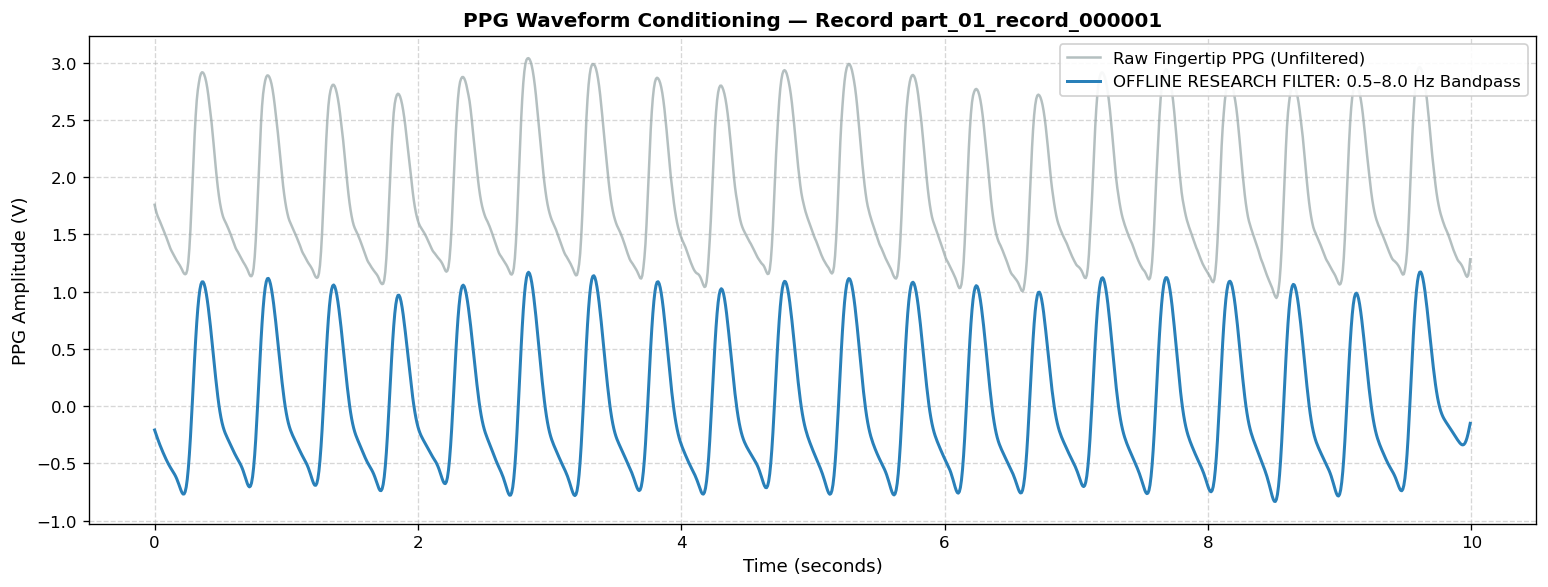

In [8]:
fig, ax = plt.subplots(figsize=(13, 5), dpi=120)
ax.plot(t, ppg_raw, color='#95a5a6', alpha=0.7, lw=1.5, label='Raw Fingertip PPG (Unfiltered)')
ax.plot(t, ppg_filtered, color='#2980b9', lw=1.8, label='OFFLINE RESEARCH FILTER: 0.5–8.0 Hz Bandpass')
ax.set_title(f"PPG Waveform Conditioning — Record {valid_rec_id}", fontsize=12, fontweight='bold')
ax.set_xlabel("Time (seconds)", fontsize=11)
ax.set_ylabel("PPG Amplitude (V)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 9. Arterial Blood Pressure (ABP) Waveform & Diagnostic Beat Detection

Using `find_peaks(abp, prominence=10)` to detect cardiac cycles and compute beat-by-beat SBP and DBP ground truth.

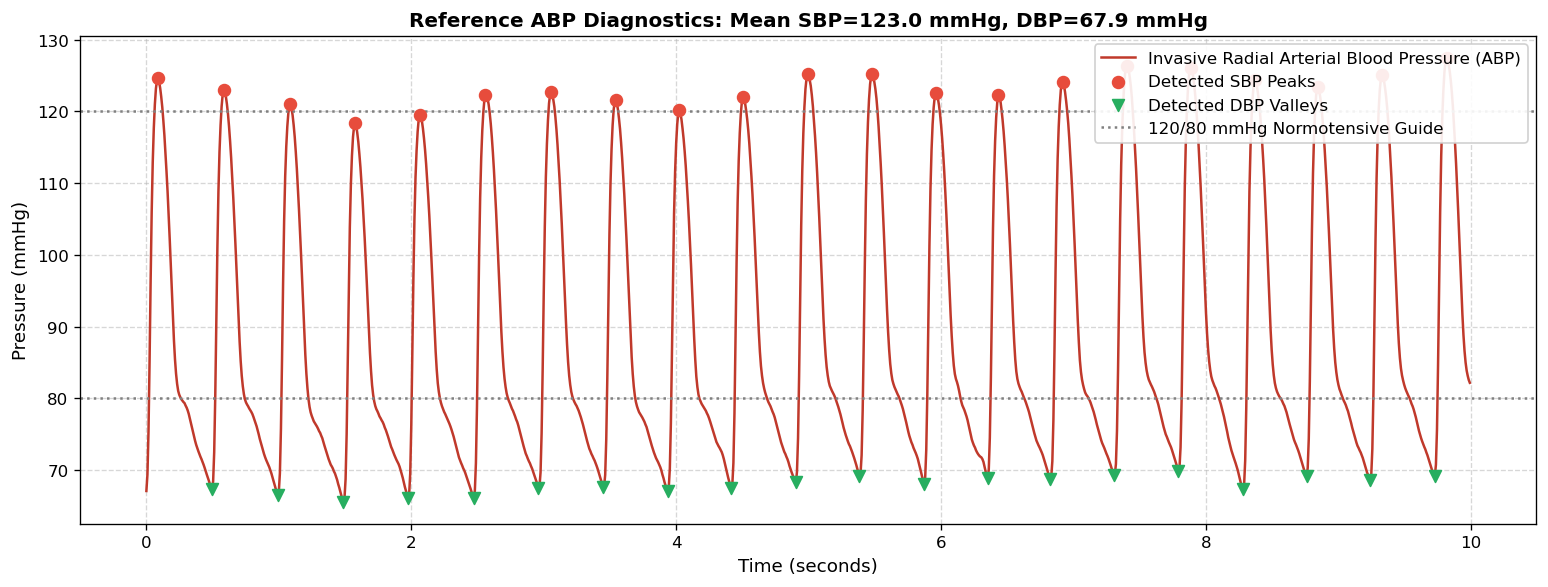

In [9]:
from data.preprocessing import extract_physiological_bp_targets

abp_raw = sample_record['abp'][:1250]
bp_res = extract_physiological_bp_targets(abp_raw, fs=SAMPLING_RATE)

fig, ax = plt.subplots(figsize=(13, 5), dpi=120)
ax.plot(t, abp_raw, color='#c0392b', lw=1.5, label='Invasive Radial Arterial Blood Pressure (ABP)')
if bp_res['is_valid']:
    p_idx = bp_res['peak_indices']
    t_idx = bp_res['trough_indices']
    ax.scatter(p_idx / SAMPLING_RATE, abp_raw[p_idx], color='#e74c3c', s=50, zorder=5, label='Detected SBP Peaks')
    ax.scatter(t_idx / SAMPLING_RATE, abp_raw[t_idx], color='#27ae60', marker='v', s=50, zorder=5, label='Detected DBP Valleys')

ax.axhline(120, color='gray', linestyle=':', label='120/80 mmHg Normotensive Guide')
ax.axhline(80, color='gray', linestyle=':')
ax.set_title(f"Reference ABP Diagnostics: Mean SBP={bp_res.get('sbp_mean', np.nan):.1f} mmHg, DBP={bp_res.get('dbp_mean', np.nan):.1f} mmHg", fontsize=12, fontweight='bold')
ax.set_xlabel("Time (seconds)", fontsize=11)
ax.set_ylabel("Pressure (mmHg)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 10. Synchronized PPG + ABP Alignment

Visualizing cardiac ejection wave transmission from central arterial pressure to peripheral optical photoplethysmogram.

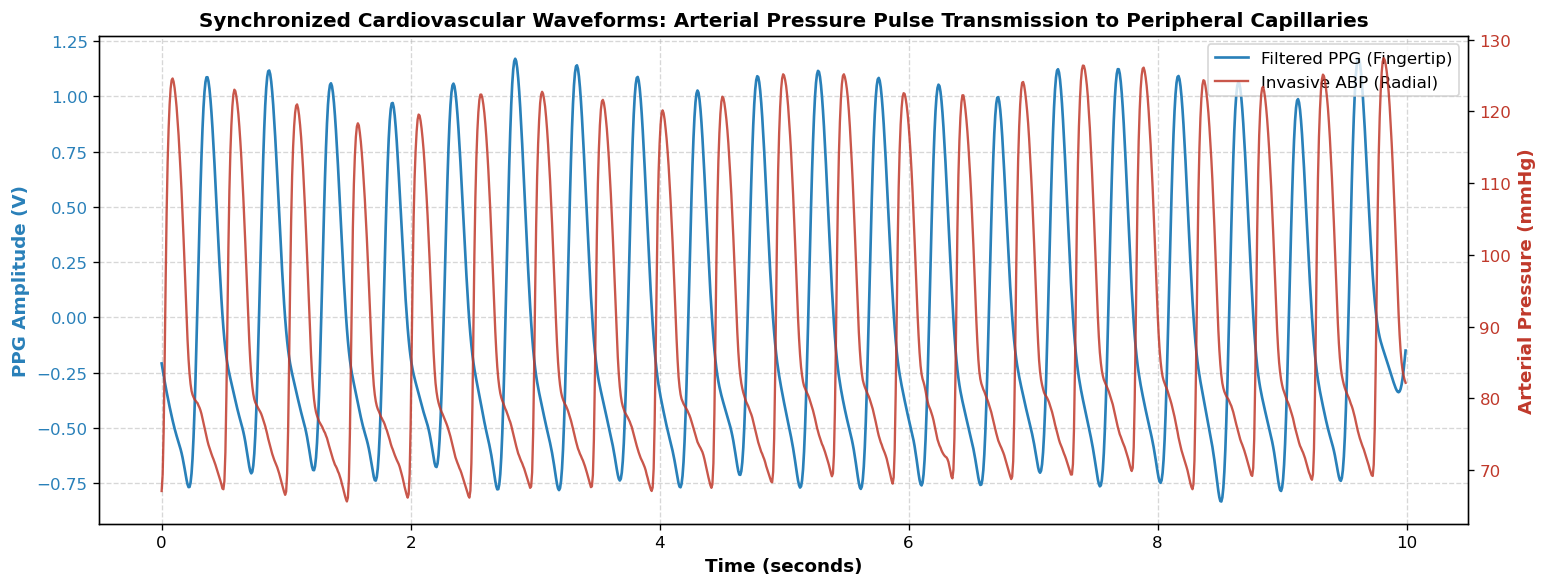

In [10]:
fig, ax1 = plt.subplots(figsize=(13, 5), dpi=120)
ax2 = ax1.twinx()

l1 = ax1.plot(t, ppg_filtered, color='#2980b9', lw=1.6, label='Filtered PPG (Fingertip)')
l2 = ax2.plot(t, abp_raw, color='#c0392b', lw=1.4, alpha=0.85, label='Invasive ABP (Radial)')

ax1.set_xlabel("Time (seconds)", fontsize=11, fontweight='bold')
ax1.set_ylabel("PPG Amplitude (V)", color='#2980b9', fontsize=11, fontweight='bold')
ax2.set_ylabel("Arterial Pressure (mmHg)", color='#c0392b', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax2.tick_params(axis='y', labelcolor='#c0392b')

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.title("Synchronized Cardiovascular Waveforms: Arterial Pressure Pulse Transmission to Peripheral Capillaries", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Dataset Quality Statistics Summary

In [11]:
from data.dataset_statistics import compute_dataset_qc_statistics

stats = compute_dataset_qc_statistics(df_manifest)

dur_stats = stats['duration_statistics']
ppg_stats = stats['ppg_signal_diagnostics']
abp_stats = stats['abp_reference_diagnostics']

print("================ DATASET PROFILE ================")
print(f"Total Evaluated Records : {stats['total_records']:,}")
print(f"Duration Range          : {dur_stats['min_sec']:.1f}s – {dur_stats['max_sec']:.1f}s (Median: {dur_stats['median_sec']:.1f}s)")
print(f"PPG PTP Amplitude Median: {ppg_stats.get('ptp_median', 0):.3f} V (5th-95th: [{ppg_stats.get('ptp_p05', 0):.3f}, {ppg_stats.get('ptp_p95', 0):.3f}] V)")
print(f"SBP Ground Truth Mean   : {abp_stats.get('sbp_mean', 0):.1f} ± {abp_stats.get('sbp_std', 0):.1f} mmHg")
print(f"DBP Ground Truth Mean   : {abp_stats.get('dbp_mean', 0):.1f} ± {abp_stats.get('dbp_std', 0):.1f} mmHg")
print(f"MAP Ground Truth Mean   : {abp_stats.get('map_mean', 0):.1f} ± {abp_stats.get('map_std', 0):.1f} mmHg")
print(f"Estimated Mean HR       : {abp_stats.get('hr_mean', 0):.1f} ± {abp_stats.get('hr_std', 0):.1f} bpm")
print("=================================================")

================ DATASET PROFILE ================
Total Evaluated Records : 12,000
Duration Range          : 8.0s – 592.0s (Median: 160.0s)
PPG PTP Amplitude Median: 2.694 V (5th-95th: [0.580, 4.002] V)
SBP Ground Truth Mean   : 127.2 ± 21.9 mmHg
DBP Ground Truth Mean   : 65.7 ± 11.1 mmHg
MAP Ground Truth Mean   : 87.4 ± 13.6 mmHg
Estimated Mean HR       : 87.6 ± 15.7 bpm


## 12. Dataset Distribution Visualizations

Inspecting the global distributions of signal durations, amplitudes, and reference blood pressure levels.

In [12]:
from visualization.dataset_plots import (
    plot_record_duration_distribution,
    plot_ppg_amplitude_distribution,
    plot_sbp_distribution,
    plot_dbp_distribution
)

plot_record_duration_distribution(df_manifest)
plot_ppg_amplitude_distribution(df_manifest)
plot_sbp_distribution(df_manifest)
plot_dbp_distribution(df_manifest)

print(f"All distribution plots saved under: {FIGURES_DIR}")

All distribution plots saved under: /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/code/outputs/figures


## 13. Rejection & Anomaly Analysis

In [13]:
from visualization.dataset_plots import (
    plot_quality_status_breakdown,
    plot_rejection_reasons_breakdown
)

plot_quality_status_breakdown(df_manifest)
plot_rejection_reasons_breakdown(df_manifest)

print("Quality control breakdown figures successfully updated.")

Quality control breakdown figures successfully updated.


## 14. Final Dataset Summary & Phase 2 Readiness

**Summary of Phase 1 Deliverables**:
1. `code/outputs/statistics/dataset_qc_manifest.csv`: Audited quality-control manifest recording structural, PPG, and ABP validity for every record.
2. `code/outputs/statistics/DATASET_QUALITY_REPORT.md`: Comprehensive analytical audit report.
3. `code/outputs/figures/`: Multi-scale signal waveforms and distribution plots.
4. `BloodPressureDataset/`: 100% untouched raw source files.

**Phase 2 Readiness**: The dataset manifest provides clean, un-corrupted record identifiers ready for record-level grouping and strictly PPG-only blood pressure estimation modeling.